In [158]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [159]:
df = pd.DataFrame()

df['X1'] = [2, 3, 4, 6, 7, 8, 9, 10]
df['X2'] = [8, 7, 5, 6, 2, 3, 4, 1]
df['label'] = [1, 1, 1, 0, 0, 0, 1, 0]

df

,X1,X2,label
0,2,8,1
1,3,7,1
2,4,5,1
3,6,6,0
4,7,2,0
5,8,3,0
6,9,4,1
7,10,1,0


<Axes: xlabel='X1', ylabel='X2'>

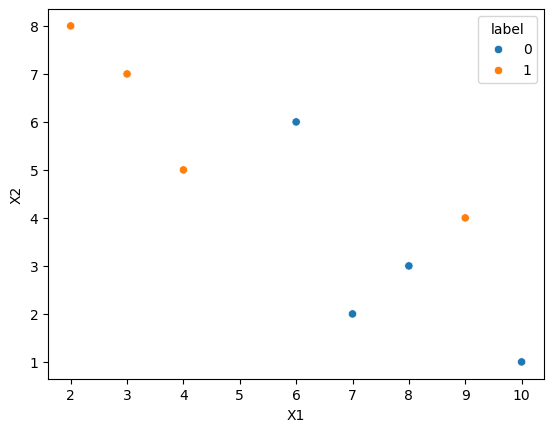

In [160]:
import seaborn as sns

sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [161]:
df['weights'] = 1 / df.shape[0]

In [162]:
df['weights'].sum()

np.float64(1.0)

In [163]:
df

,X1,X2,label,weights
0,2,8,1,0.125
1,3,7,1,0.125
2,4,5,1,0.125
3,6,6,0,0.125
4,7,2,0,0.125
5,8,3,0,0.125
6,9,4,1,0.125
7,10,1,0,0.125


In [164]:
from sklearn.tree import DecisionTreeClassifier

In [165]:
dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

dt1.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


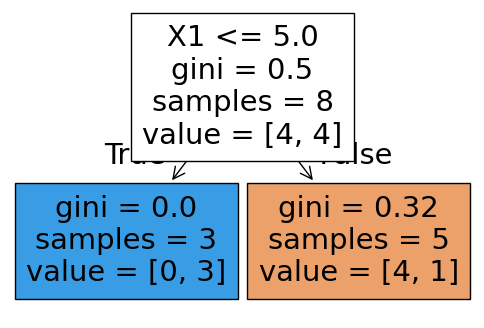

In [166]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(6,4))
plot_tree(dt1, feature_names=['X1','X2'], filled=True)
plt.show()

In [17]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 3.4 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 3.0 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 3.0 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 3.0 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 2.9 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.0 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 3.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 3.1 MB/s eta 0:00:01
   --------------------------

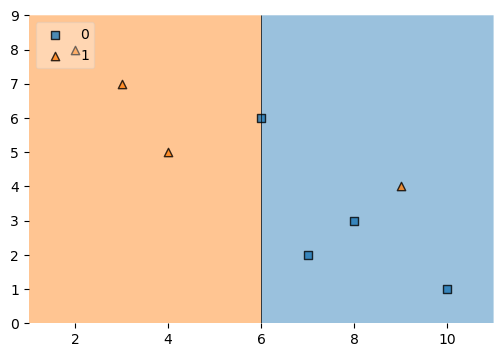

In [167]:
plt.figure(figsize=(6,4))
plot_decision_regions(X, y, clf=dt1, legend=2)
plt.show()

In [168]:
df['y_pred'] = dt1.predict(X)

In [169]:
df

,X1,X2,label,weights,y_pred
0,2,8,1,0.125,1
1,3,7,1,0.125,1
2,4,5,1,0.125,1
3,6,6,0,0.125,0
4,7,2,0,0.125,0
5,8,3,0,0.125,0
6,9,4,1,0.125,0
7,10,1,0,0.125,0


In [170]:
def calculate_model_weight(error):
    return 0.5 * np.log((1 - error) / error)

In [171]:
# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.125)
alpha1

np.float64(0.9729550745276566)

In [172]:
def update_row_weights(row, alpha):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

## Why Do We Use exp(-alpha) for Correct Predictions?

### Key Idea

AdaBoost is designed to **focus more on mistakes**, not reward correct predictions.

---

### Weight Update Logic

- If prediction is correct:

$$
w = w \cdot e^{-\alpha}
$$

- If prediction is wrong:

$$
w = w \cdot e^{\alpha}
$$

---

### Intuition Using Graph of $$e^x$$

- $$e^{\alpha}$$ → increases rapidly (boosts weight)  
- $$e^{-\alpha}$$ → decreases rapidly (reduces weight)  

---

### What This Means

- **Correct predictions**:
  - Weight decreases  
  - These points become less important  
  - Model has already learned them  

- **Wrong predictions**:
  - Weight increases  
  - These points become more important  
  - Model needs to focus on them  

---

### Role of Alpha

- Large $$\alpha$$ (good model):
  - Strongly decreases weight of correct points  
  - Strongly increases weight of wrong points  

- Small $$\alpha$$ (weak model):
  - Small changes in weights  

---

### Final Intuition

- Easy points → ignored over time  
- Hard points → get more focus  

AdaBoost shifts learning toward **difficult examples** by adjusting weights exponentially.

In [173]:
df['updated_weights'] = df.apply(update_row_weights, axis=1, alpha=alpha1)

In [174]:
df['updated_weights'] .sum()

np.float64(0.6614378277661477)

> Normalizing weight

In [175]:
df['normalized_weight'] = df['updated_weights'] / df['updated_weights'].sum()

In [176]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weight
0,2,8,1,0.125,1,0.047246,0.071429
1,3,7,1,0.125,1,0.047246,0.071429
2,4,5,1,0.125,1,0.047246,0.071429
3,6,6,0,0.125,0,0.047246,0.071429
4,7,2,0,0.125,0,0.047246,0.071429
5,8,3,0,0.125,0,0.047246,0.071429
6,9,4,1,0.125,0,0.330719,0.500000
7,10,1,0,0.125,0,0.047246,0.071429


In [177]:
df["normalized_weight"].sum()

np.float64(0.9999999999999999)

In [178]:
np.isclose(df["normalized_weight"].sum(), 1)

np.True_

### creating ranges

In [179]:
df['cumsum_upper'] = np.cumsum(df['normalized_weight'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weight']

In [180]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weight,cumsum_upper,cumsum_lower
0,2,8,1,0.125,1,0.047246,0.071429,0.071429,0.000000
1,3,7,1,0.125,1,0.047246,0.071429,0.142857,0.071429
2,4,5,1,0.125,1,0.047246,0.071429,0.214286,0.142857
3,6,6,0,0.125,0,0.047246,0.071429,0.285714,0.214286
4,7,2,0,0.125,0,0.047246,0.071429,0.357143,0.285714
5,8,3,0,0.125,0,0.047246,0.071429,0.428571,0.357143
6,9,4,1,0.125,0,0.330719,0.500000,0.928571,0.428571
7,10,1,0,0.125,0,0.047246,0.071429,1.000000,0.928571


#### creating new dataset

In [181]:
def create_new_dataset(df):
    indices = []

    for _ in range(df.shape[0]):
        a = np.random.random()

        for index, row in df.iterrows():
            if row['cumsum_lower'] <= a < row['cumsum_upper']:
                indices.append(index)
                break   # important: stop after finding match

    return indices

In [182]:
index_values = create_new_dataset(df)

In [183]:
index_values

[6, 7, 6, 3, 0, 6, 5, 6]

In [184]:
second_df = df.iloc[index_values].copy()
second_df.reset_index(drop=True, inplace=True)

In [185]:
second_df = second_df[['X1', 'X2', 'label']]
second_df['weights'] = 1 / second_df.shape[0]

In [186]:
second_df

,X1,X2,label,weights
0,9,4,1,0.125
1,10,1,0,0.125
2,9,4,1,0.125
3,6,6,0,0.125
4,2,8,1,0.125
5,9,4,1,0.125
6,8,3,0,0.125
7,9,4,1,0.125


In [187]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [188]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt2.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 3.5\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.625, 0.5, '  False')]

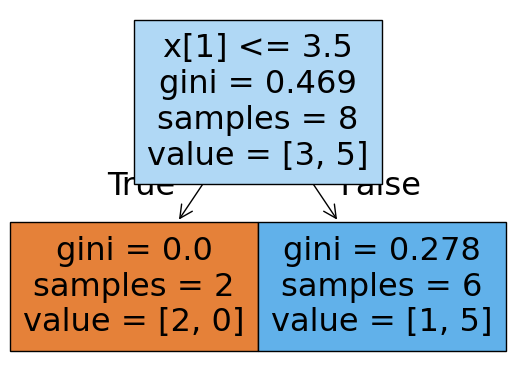

In [189]:
plot_tree(dt2 , filled=True)

<Axes: >

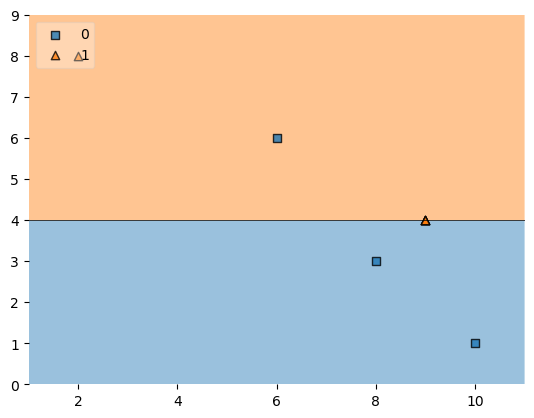

In [190]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [191]:
second_df['y_pred'] = dt2.predict(X)

In [192]:
second_df

,X1,X2,label,weights,y_pred
0,9,4,1,0.125,1
1,10,1,0,0.125,0
2,9,4,1,0.125,1
3,6,6,0,0.125,1
4,2,8,1,0.125,1
5,9,4,1,0.125,1
6,8,3,0,0.125,0
7,9,4,1,0.125,1


In [195]:
df['y_pred2'] = dt2.predict(df[['X1','X2']].values)

In [196]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weight,cumsum_upper,cumsum_lower,y_pred2
0,2,8,1,0.125,1,0.047246,0.071429,0.071429,0.000000,1
1,3,7,1,0.125,1,0.047246,0.071429,0.142857,0.071429,1
2,4,5,1,0.125,1,0.047246,0.071429,0.214286,0.142857,1
3,6,6,0,0.125,0,0.047246,0.071429,0.285714,0.214286,1
4,7,2,0,0.125,0,0.047246,0.071429,0.357143,0.285714,0
5,8,3,0,0.125,0,0.047246,0.071429,0.428571,0.357143,0
6,9,4,1,0.125,0,0.330719,0.500000,0.928571,0.428571,1
7,10,1,0,0.125,0,0.047246,0.071429,1.000000,0.928571,0


In [199]:
error2 = (df['weights'] * (df['label'] != df['y_pred2'])).sum()
error2

np.float64(0.125)

In [201]:
alpha2 = calculate_model_weight(error2)
alpha2

np.float64(0.9729550745276566)

In [202]:
df['updated_weights2'] = df.apply(update_row_weights, axis=1, alpha=alpha2)

In [203]:
df['normalized_weight2'] = df['updated_weights2'] / df['updated_weights2'].sum()

In [204]:
df['cumsum_upper2'] = np.cumsum(df['normalized_weight2'])
df['cumsum_lower2'] = df['cumsum_upper2'] - df['normalized_weight2']

In [205]:
indices2 = create_new_dataset(df)
indices2

[1, 2, 6, 4, 6, 7, 6, 6]

## creating third data 

In [206]:
third_df = df.iloc[indices2].copy()
third_df.reset_index(drop=True, inplace=True)

third_df = third_df[['X1','X2','label']]
third_df['weights'] = 1 / third_df.shape[0]

In [207]:
third_df

,X1,X2,label,weights
0,3,7,1,0.125
1,4,5,1,0.125
2,9,4,1,0.125
3,7,2,0,0.125
4,9,4,1,0.125
5,10,1,0,0.125
6,9,4,1,0.125
7,9,4,1,0.125


In [208]:
from sklearn.tree import DecisionTreeClassifier

dt3 = DecisionTreeClassifier(max_depth=1)

X3 = third_df[['X1','X2']].values
y3 = third_df['label'].values

dt3.fit(X3, y3)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [209]:
df['y_pred3'] = dt3.predict(df[['X1','X2']].values)

In [210]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weight,cumsum_upper,cumsum_lower,y_pred2,updated_weights2,normalized_weight2,cumsum_upper2,cumsum_lower2,y_pred3
0,2,8,1,0.125,1,0.047246,0.071429,0.071429,0.000000,1,0.047246,0.071429,0.071429,0.000000,1
1,3,7,1,0.125,1,0.047246,0.071429,0.142857,0.071429,1,0.047246,0.071429,0.142857,0.071429,1
2,4,5,1,0.125,1,0.047246,0.071429,0.214286,0.142857,1,0.047246,0.071429,0.214286,0.142857,1
3,6,6,0,0.125,0,0.047246,0.071429,0.285714,0.214286,1,0.047246,0.071429,0.285714,0.214286,1
4,7,2,0,0.125,0,0.047246,0.071429,0.357143,0.285714,0,0.047246,0.071429,0.357143,0.285714,0
5,8,3,0,0.125,0,0.047246,0.071429,0.428571,0.357143,0,0.047246,0.071429,0.428571,0.357143,0
6,9,4,1,0.125,0,0.330719,0.500000,0.928571,0.428571,1,0.330719,0.500000,0.928571,0.428571,1
7,10,1,0,0.125,0,0.047246,0.071429,1.000000,0.928571,0,0.047246,0.071429,1.000000,0.928571,0


In [213]:
df[['label', 'y_pred', 'y_pred3']]

,label,y_pred,y_pred3
0,1,1,1
1,1,1,1
2,1,1,1
3,0,0,1
4,0,0,0
5,0,0,0
6,1,0,1
7,0,0,0


In [216]:
error3 = (df['weights'] * (df['label'] != df['y_pred3'])).sum()
error3

np.float64(0.5)

In [217]:
alpha3 = calculate_model_weight(error3)
alpha3

np.float64(0.0)

## Observation: alpha3 = 0

When error = 0.5:

$$
\alpha = \frac{1}{2} \ln \left( \frac{1 - error}{error} \right) = 0
$$

This means the third model (m3) has no contribution in the final prediction.

---

## Implication

Since:

$$
\alpha_3 = 0
$$

The final model becomes:

$$
h(x) = \text{sign} \left( \alpha_1 h_1(x) + \alpha_2 h_2(x) \right)
$$

So we can ignore the third model.

---

## Important Clarification

We should NOT modify the formula artificially (e.g., adding a small value to the denominator) to avoid zero.

- If error = 0.5, the model is equivalent to random guessing  
- Giving it any weight would be incorrect  

---

## Practical Understanding

- AdaBoost naturally assigns:
  - High weight to good models  
  - Zero weight to random models  

- Libraries like sklearn handle edge cases internally, but the core logic remains the same  

---

## Final Insight

A model with error = 0.5 carries no useful information, so AdaBoost automatically ignores it.

# ignoring m3

In [218]:
df['final_score'] = (
    alpha1 * df['y_pred'] +
    alpha2 * df['y_pred2']
)

df['final_pred'] = np.sign(df['final_score'])

In [219]:
df['final_pred'] = df['final_pred'].map({-1: 0, 1: 1})

In [220]:
df['final_pred'] = df['final_pred'].map({-1: 0, 1: 1})

In [221]:
acc_m1 = (df['label'] == df['y_pred']).mean()
acc_m2 = (df['label'] == df['y_pred2']).mean()
acc_final = (df['label'] == df['final_pred']).mean()

acc_m1, acc_m2, acc_final

(np.float64(0.375), np.float64(0.5), np.float64(0.375))

In [222]:
print(f"Accuracy m1: {acc_m1:.2f}")
print(f"Accuracy m2: {acc_m2:.2f}")
print(f"Final Accuracy (AdaBoost): {acc_final:.2f}")

Accuracy m1: 0.38
Accuracy m2: 0.50
Final Accuracy (AdaBoost): 0.38


In [223]:
print("Improvement over m1:", acc_final - acc_m1)

Improvement over m1: 0.0


## Final Notes

This notebook was focused on understanding the **core idea of AdaBoost**, rather than achieving high accuracy.

We implemented AdaBoost from scratch and explored:

- How weak learners (decision stumps) are trained
- How errors are calculated using weights
- How model importance (alpha) is computed
- How weights shift toward misclassified points
- How sampling creates a new dataset for the next learner
- How multiple weak learners are combined into a final model

---

## Key Learnings

- AdaBoost works by **sequentially correcting mistakes**
- Each new model focuses more on **hard-to-classify points**
- Weights play a central role in guiding learning
- Final prediction is a **weighted combination of all models**

---

## Important Observations

- With a very small dataset, improvement may not always be visible  
- Weak learners may sometimes conflict with each other  
- A model with error = 0.5 gets zero importance (alpha = 0)  
- AdaBoost is more effective with:
  - More data
  - More iterations
  - Slightly stronger base learners  

---

## Final Thought

The goal of this notebook was not just to use AdaBoost, but to **understand how it works internally**.

Building it step by step provides much deeper intuition than using a library directly.

---